---
## ⚙️ Setup — Run this first!

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# Check if GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Go to Runtime → Change runtime type → GPU")
    print("   (Some demos will still work, just slower)")

print("\n✅ Setup complete! Ready to go.")

PyTorch version: 2.9.0+cu128
GPU available: True
GPU name: Tesla T4

✅ Setup complete! Ready to go.


---
# Part 1: Tensors — Building Intuition
*(After Slides 4-11)*

---

### 1.1 Scalars, Vectors, Matrices, Tensors
Let's create each one and see what makes them different.

In [ ]:
rishabh_age = torch.tensor(20.0)

In [ ]:
print(rishabh_age)

tensor(20.)


In [ ]:
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])

In [ ]:
print(vector)

tensor([1., 2., 3., 4.])


In [ ]:
print(vector.dim())

1


In [ ]:
print(rishabh_age.dim())

0


In [ ]:
# A scalar — just a number
scalar = torch.tensor(42.0)
print(f"Scalar: {scalar}")
print(f"  Shape: {scalar.shape}")      # torch.Size([])
print(f"  Dimensions: {scalar.dim()}")  # 0
print()

# A vector — a list of numbers
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"Vector: {vector}")
print(f"  Shape: {vector.shape}")      # torch.Size([4])
print(f"  Dimensions: {vector.dim()}")  # 1
print()

# A matrix — a grid of numbers
matrix = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])
print(f"Matrix:\n{matrix}")
print(f"  Shape: {matrix.shape}")      # torch.Size([2, 3])
print(f"  Dimensions: {matrix.dim()}")  # 2
print()

# A 3D tensor — a cube of numbers
tensor_3d = torch.zeros(2, 3, 4)
print(f"3D Tensor shape: {tensor_3d.shape}")    # [2, 3, 4]
print(f"  Dimensions: {tensor_3d.dim()}")        # 3
print()

# A 4D tensor — like a batch going through multi-head attention
tensor_4d = torch.zeros(8, 12, 3, 64)
print(f"4D Tensor shape: {tensor_4d.shape}")    # [8, 12, 3, 64]
print(f"  That's: 8 sentences × 12 heads × 3 tokens × 64 dims")

Scalar: 42.0
  Shape: torch.Size([])
  Dimensions: 0

Vector: tensor([1., 2., 3., 4.])
  Shape: torch.Size([4])
  Dimensions: 1

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
  Shape: torch.Size([2, 3])
  Dimensions: 2

3D Tensor shape: torch.Size([2, 3, 4])
  Dimensions: 3

4D Tensor shape: torch.Size([8, 12, 3, 64])
  That's: 8 sentences × 12 heads × 3 tokens × 64 dims


### 1.2 Creating Tensors — Many Ways

In [ ]:
z = torch.zeros(3, 4)

In [ ]:
o = torch.ones(2, 5)

In [ ]:
r = torch.randn(3,3)

In [ ]:
seq = torch.arange(0, 10)

In [ ]:
lin = torch.linspace(0, 1, 5)

In [ ]:
# Zeros and ones
z = torch.zeros(3, 4)        # 3×4 matrix of zeros
o = torch.ones(2, 5)         # 2×5 matrix of ones

# Random (normal distribution) — this is how weights start!
r = torch.randn(3, 3)        # random values, mean=0, std=1
print("Random matrix (this is how neural network weights begin):")
print(r)
print()

# From a range
seq = torch.arange(0, 10)    # [0, 1, 2, ..., 9]
print(f"Sequence: {seq}")

# Linspace — evenly spaced
lin = torch.linspace(0, 1, 5)  # 5 values from 0 to 1
print(f"Linspace: {lin}")

Random matrix (this is how neural network weights begin):
tensor([[ 0.3691, -0.8145,  1.8882],
        [ 0.2480, -0.4408,  0.6973],
        [ 0.7339,  1.2655,  2.2721]])

Sequence: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


### 1.3 Shape is Everything
In deep learning, you'll check `.shape` more than anything else.

In [ ]:
torch.permute()

In [ ]:
# Real-world shapes in deep learning:
batch_size = 8
seq_len = 128
embed_dim = 768
num_heads = 12
head_dim = embed_dim // num_heads  # 64

# A batch of tokenized sentences
x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Batch of sentences: {x.shape}")
print(f"  {batch_size} sentences, {seq_len} tokens each, {embed_dim} dimensions per token")
print()

# Reshape for multi-head attention
x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"After splitting into heads: {x_heads.shape}")
print(f"  {batch_size} sentences, {seq_len} tokens, {num_heads} heads, {head_dim} dims per head")
print()

# Rearrange so heads come before tokens (needed for attention)
x_ready = x_heads.permute(0, 2, 1, 3)
print(f"After permute for attention: {x_ready.shape}")
print(f"  {batch_size} sentences, {num_heads} heads, {seq_len} tokens, {head_dim} dims")
print()
print("☝️ This is EXACTLY what happens inside every transformer!")

Batch of sentences: torch.Size([8, 128, 768])
  8 sentences, 128 tokens each, 768 dimensions per token

After splitting into heads: torch.Size([8, 128, 12, 64])
  8 sentences, 128 tokens, 12 heads, 64 dims per head

After permute for attention: torch.Size([8, 12, 128, 64])
  8 sentences, 12 heads, 128 tokens, 64 dims

☝️ This is EXACTLY what happens inside every transformer!


### 🛑 Try It Yourself
1. Create a tensor of shape `[4, 10, 512]` (4 sentences, 10 tokens, 512 dims)
2. Check its shape and number of dimensions
3. Reshape it to `[4, 10, 8, 64]` (split into 8 attention heads)
4. Permute it to `[4, 8, 10, 64]`

### → Back to slides for Part 2: Matrix Magic

---
# Part 2: Matrix Magic — Transformations Visualized
*(After Slides 12-21)*

---

### 2.1 Matrix × Vector = Transformation
A matrix doesn't just store numbers — it *transforms* vectors.

In [ ]:
# A vector pointing right
v = torch.tensor([1.0, 0.0])
print(f"Original vector: {v.tolist()}")

# Rotation matrix (90 degrees counterclockwise)
rotate_90 = torch.tensor([[0., -1.],
                           [1.,  0.]])

rotated = rotate_90 @ v
print(f"After 90° rotation: {rotated.tolist()}")  # [0, 1] → pointing up!

# Rotation matrix (45 degrees)
angle = math.radians(45)
rotate_45 = torch.tensor([[math.cos(angle), -math.sin(angle)],
                           [math.sin(angle),  math.cos(angle)]])

rotated_45 = rotate_45 @ v
print(f"After 45° rotation: [{rotated_45[0]:.3f}, {rotated_45[1]:.3f}]")

Original vector: [1.0, 0.0]
After 90° rotation: [0.0, 1.0]
After 45° rotation: [0.707, 0.707]


### 2.2 🔥 Visualizing Transformations
Watch a matrix transform an entire grid of points!

In [ ]:
def plot_transformation(matrix, title="Transformation"):
    """Visualize how a 2x2 matrix transforms a grid of points."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Create a grid of points
    n = 10
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)

    # Plot original grid
    ax = axes[0]
    ax.set_title("Original", fontsize=14, fontweight='bold')
    for xi in x:
        ax.plot([xi]*n, y, 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        ax.plot(x, [yi]*n, 'b-', alpha=0.3, linewidth=1)

    # Highlight a square
    square_x = [0, 1, 1, 0, 0]
    square_y = [0, 0, 1, 1, 0]
    ax.plot(square_x, square_y, 'r-', linewidth=3)

    # Arrow for basis vectors
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Plot transformed grid
    M = np.array(matrix)
    ax = axes[1]
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')

    for xi in x:
        points = np.array([[xi, yi] for yi in y])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        points = np.array([[xi, yi] for xi in x])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)

    # Transform the square
    sq = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    sq_t = M @ sq
    ax.plot(sq_t[0], sq_t[1], 'r-', linewidth=3)

    # Transform basis vectors
    e1_t = M @ np.array([1, 0])
    e2_t = M @ np.array([0, 1])
    ax.annotate('', xy=e1_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=e2_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function ready! Run the cells below.")

✅ Visualization function ready! Run the cells below.


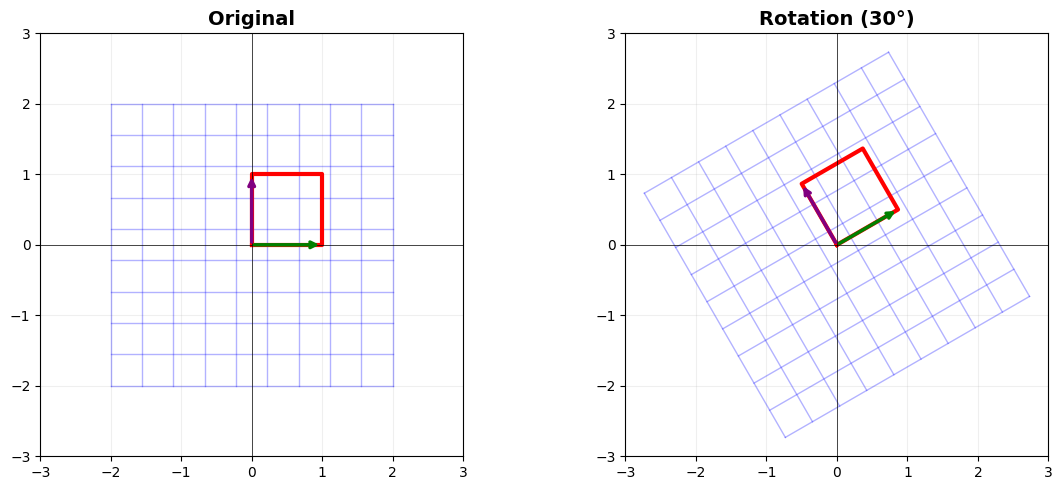

In [ ]:
# 🔥 ROTATION — the grid spins!
angle = math.radians(30)
rotation = [[math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]]
plot_transformation(rotation, "Rotation (30°)")

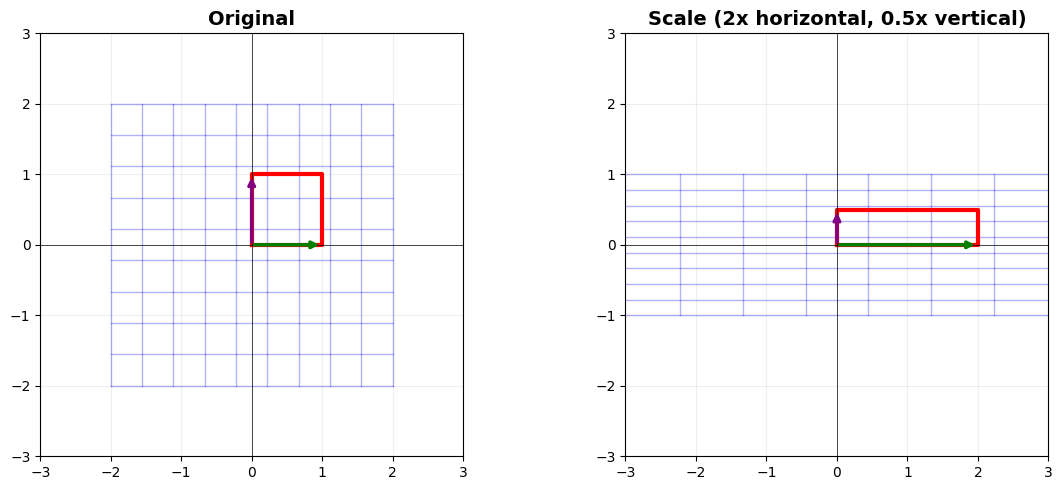

In [ ]:
# 🔥 SCALING — stretch and squish!
plot_transformation([[2, 0], [0, 0.5]], "Scale (2x horizontal, 0.5x vertical)")

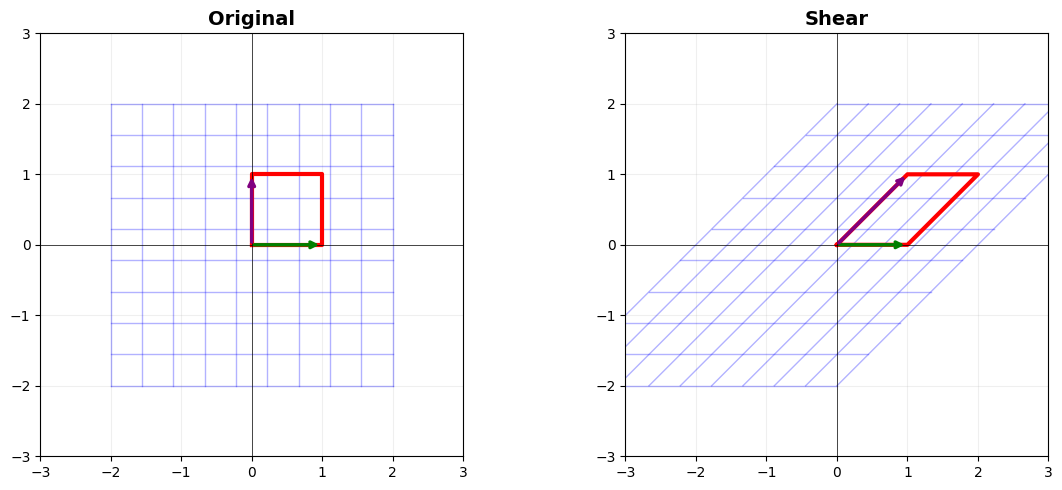

In [ ]:
# 🔥 SHEAR — lean it sideways!
plot_transformation([[1, 1], [0, 1]], "Shear")

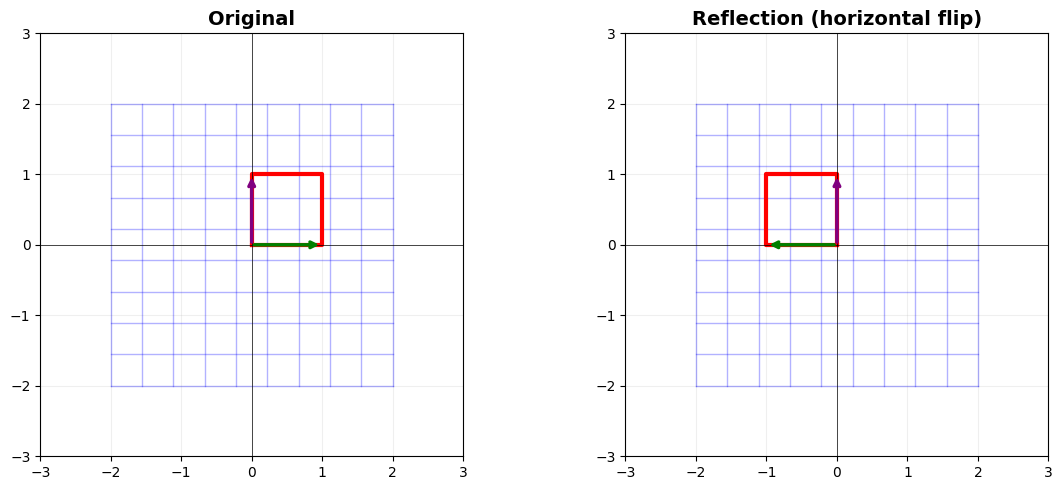

In [ ]:
# 🔥 REFLECTION — flip it!
plot_transformation([[-1, 0], [0, 1]], "Reflection (horizontal flip)")

### 🛑 Try It Yourself
Change the numbers and see what happens!
- What does `[[0, 1], [1, 0]]` do? (swap x and y!)
- What does `[[2, 0], [0, 2]]` do? (uniform scale)
- What does `[[1, 0], [0, -1]]` do? (vertical flip)
- What about `[[0.5, -0.5], [0.5, 0.5]]`? (rotate + shrink)

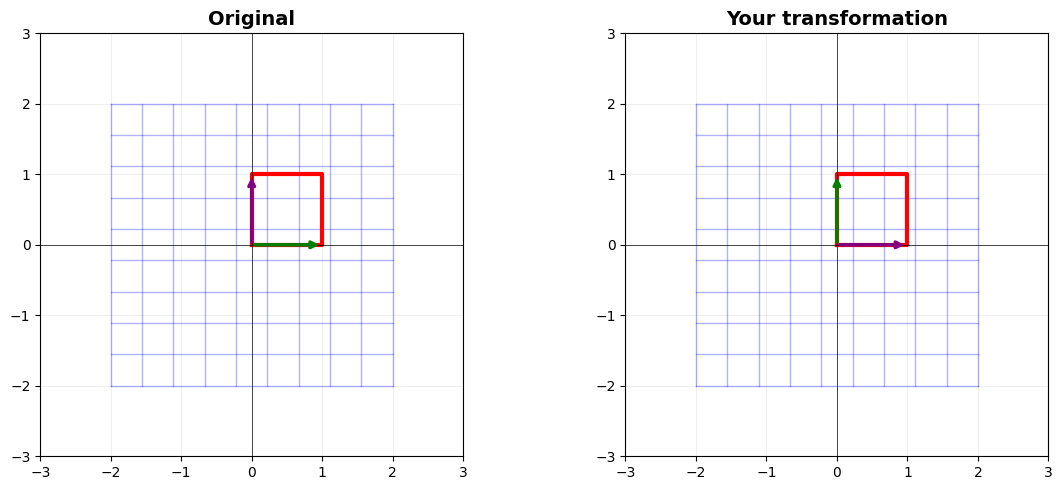

In [ ]:
# Try your own transformation!
plot_transformation([[0, 1], [1, 0]], "Your transformation")

### 2.3 The Dot Product — Measuring Similarity
The atom of deep learning.

In [ ]:
# Two similar vectors (pointing roughly the same way)
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([1.1, 1.9, 3.1])
print(f"Similar vectors dot product: {a @ b:.2f}")  # high!

# Two perpendicular vectors
c = torch.tensor([1.0, 0.0])
d = torch.tensor([0.0, 1.0])
print(f"Perpendicular dot product:   {c @ d:.2f}")  # zero!

# Two opposite vectors
e = torch.tensor([1.0, 2.0])
f = torch.tensor([-1.0, -2.0])
print(f"Opposite vectors dot product: {e @ f:.2f}")  # negative!

print()
print("☝️ This is EXACTLY what attention does:")
print("   Q · K = how much should this word attend to that word?")

Similar vectors dot product: 14.20
Perpendicular dot product:   0.00
Opposite vectors dot product: -5.00

☝️ This is EXACTLY what attention does:
   Q · K = how much should this word attend to that word?


### 2.5 Matrix Multiplication Speed
Python loops vs PyTorch — feel the difference.

In [ ]:
# Multiply two matrices using Python loops (the slow way)
def matmul_slow(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    C = torch.zeros(rows_A, cols_B)
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]
    return C

size = 100
A = torch.randn(size, size)
B = torch.randn(size, size)

# Slow way
start = time.time()
C_slow = matmul_slow(A, B)
slow_time = time.time() - start

# Fast way (PyTorch optimized)
start = time.time()
C_fast = A @ B
fast_time = time.time() - start

print(f"Matrix multiply {size}×{size}:")
print(f"  Python loops: {slow_time:.4f} seconds")
print(f"  PyTorch @:    {fast_time:.6f} seconds")
print(f"  Speedup:      {slow_time/fast_time:.0f}x faster! 🚀")
print()

Matrix multiply 100×100:
  Python loops: 18.4868 seconds
  PyTorch @:    0.012059 seconds
  Speedup:      1533x faster! 🚀



---
# Part 3: PyTorch — GPU Power
*(After Slides 22-27)*

---

In [ ]:
x = torch.randn(3, 4)
print(f"Shape: {x.shape}")
print(f"Data pointer: {x.data_ptr()}")

y = x.view(4, 3)
print(f"\nAfter view(4, 3):")
print(f"Shape: {y.shape}")
print(f"Data pointer: {y.data_ptr()}")  # SAME pointer!
print(f"\nSame memory? {x.data_ptr() == y.data_ptr()}")  # True!

Shape: torch.Size([3, 4])
Data pointer: 630945088

After view(4, 3):
Shape: torch.Size([4, 3])
Data pointer: 630945088

Same memory? True


In [ ]:
# 1. Tensor internals
x = torch.randn(3, 4)
print(f"Shape: {x.shape}")
print(f"Stride: {x.stride()}")
print(f"Is contiguous: {x.is_contiguous()}")
print(f"Data pointer: {x.data_ptr()}")

y = x.view(4, 3)
print(f"\nReshaped — same memory? {x.data_ptr() == y.data_ptr()}")

z = x.T  # transpose
print(f"Transposed — contiguous? {z.is_contiguous()}")
print(f"Transposed stride: {z.stride()}")  # reversed!

Shape: torch.Size([3, 4])
Stride: (4, 1)
Is contiguous: True
Data pointer: 625952896

Reshaped — same memory? True
Transposed — contiguous? False
Transposed stride: (1, 4)


In [ ]:
# 2. The computation graph — peek at it
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
z = y + 2 * x + 1

print(f"z = {z.item()}")
print(f"z was created by: {z.grad_fn}")           # AddBackward
print(f"  which came from: {z.grad_fn.next_functions}")
print(f"y was created by: {y.grad_fn}")            # PowBackward
print(f"\n☝️ PyTorch recorded every operation!")
print("When you call z.backward(), it walks this chain in reverse.")

z = 16.0
z was created by: <AddBackward0 object at 0x7c435d3895a0>
  which came from: ((<AddBackward0 object at 0x7c435ae28610>, 0), (None, 0))
y was created by: <PowBackward0 object at 0x7c435d3895a0>

☝️ PyTorch recorded every operation!
When you call z.backward(), it walks this chain in reverse.


In [ ]:
# 3. Gradient accumulation — the gotcha
x = torch.tensor(3.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print(f"After first backward: x.grad = {x.grad}")   # 6.0

x.grad.zero_()
y2 = x ** 2
y2.backward()
print(f"After second backward: x.grad = {x.grad}")  # 12.0! Accumulated!

# This is why we call zero_grad()
x.grad.zero_()
y3 = x ** 2
y3.backward()
print(f"After zero + backward: x.grad = {x.grad}")  # 6.0 — fresh!

After first backward: x.grad = 6.0
After second backward: x.grad = 6.0
After zero + backward: x.grad = 6.0


### 3.1 🔥 CPU vs GPU — The Speed Test
Run this and watch the numbers. This is why GPUs matter.

Size   100×100   | CPU:     0.09ms | GPU:     0.07ms | Speedup:    1.3x
Size   500×500   | CPU:     5.17ms | GPU:     0.13ms | Speedup:   40.3x
Size  1000×1000  | CPU:    25.15ms | GPU:     0.66ms | Speedup:   38.2x
Size  2000×2000  | CPU:   189.73ms | GPU:     5.87ms | Speedup:   32.3x
Size  4000×4000  | CPU:  1474.08ms | GPU:    39.04ms | Speedup:   37.8x


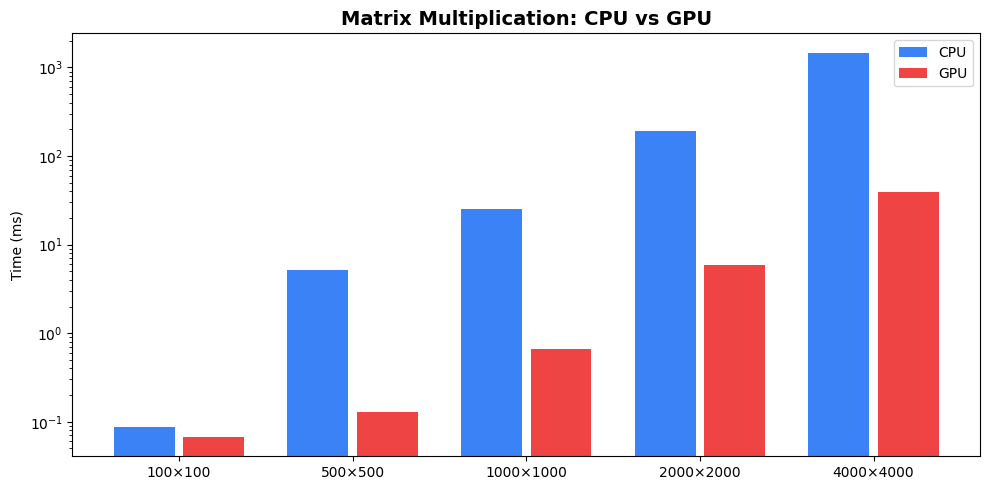


☝️ This is why NVIDIA is worth trillions.


In [ ]:
sizes = [100, 500, 1000, 2000, 4000]
cpu_times = []
gpu_times = []

for size in sizes:
    A_cpu = torch.randn(size, size)
    B_cpu = torch.randn(size, size)

    # CPU timing
    start = time.time()
    for _ in range(5):
        _ = A_cpu @ B_cpu
    cpu_time = (time.time() - start) / 5

    if torch.cuda.is_available():
        A_gpu = A_cpu.to('cuda')
        B_gpu = B_cpu.to('cuda')

        # Warmup
        _ = A_gpu @ B_gpu
        torch.cuda.synchronize()

        # GPU timing
        start = time.time()
        for _ in range(5):
            _ = A_gpu @ B_gpu
        torch.cuda.synchronize()
        gpu_time = (time.time() - start) / 5
    else:
        gpu_time = float('nan')

    cpu_times.append(cpu_time * 1000)
    gpu_times.append(gpu_time * 1000)

    speedup = cpu_time / gpu_time if gpu_time > 0 else 0
    print(f"Size {size:>5}×{size:<5} | CPU: {cpu_time*1000:>8.2f}ms | GPU: {gpu_time*1000:>8.2f}ms | Speedup: {speedup:>6.1f}x")

# Plot it
if torch.cuda.is_available():
    fig, ax = plt.subplots(figsize=(10, 5))
    x_pos = range(len(sizes))
    ax.bar([i - 0.2 for i in x_pos], cpu_times, 0.35, label='CPU', color='#3b82f6')
    ax.bar([i + 0.2 for i in x_pos], gpu_times, 0.35, label='GPU', color='#ef4444')
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([f"{s}×{s}" for s in sizes])
    ax.set_ylabel('Time (ms)')
    ax.set_title('Matrix Multiplication: CPU vs GPU', fontweight='bold', fontsize=14)
    ax.legend()
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
    print("\n☝️ This is why NVIDIA is worth trillions.")

### 3.2 Tensor Operations Playground

In [ ]:
# Basic math — element-wise
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Element-wise operations:")
print(f"  a + b = {a + b}")
print(f"  a * b = {a * b}")      # element-wise multiply
print(f"  a @ b = {a @ b}")      # dot product!
print()

# Broadcasting in action
matrix = torch.tensor([[1.0, 2.0, 3.0],
                        [4.0, 5.0, 6.0]])
bias = torch.tensor([10.0, 20.0, 30.0])

result = matrix + bias  # bias gets added to EVERY row
print("Broadcasting:")
print(f"  Matrix shape: {matrix.shape}")
print(f"  Bias shape:   {bias.shape}")
print(f"  Result:\n{result}")
print("  ☝️ Bias was added to both rows automatically!")
print()

# Useful operations
x = torch.randn(3, 4)
print(f"Random tensor:\n{x}\n")
print(f"  Mean:    {x.mean():.4f}")
print(f"  Std:     {x.std():.4f}")
print(f"  Max:     {x.max():.4f}")
print(f"  Argmax:  {x.argmax()} (index of largest element)")
print(f"  Softmax: {torch.softmax(x[0], dim=0)}")
print(f"  ☝️ Softmax turns values into probabilities (sums to 1)")

Element-wise operations:
  a + b = tensor([5., 7., 9.])
  a * b = tensor([ 4., 10., 18.])
  a @ b = 32.0

Broadcasting:
  Matrix shape: torch.Size([2, 3])
  Bias shape:   torch.Size([3])
  Result:
tensor([[11., 22., 33.],
        [14., 25., 36.]])
  ☝️ Bias was added to both rows automatically!

Random tensor:
tensor([[-0.6128,  0.9156,  1.8060, -0.6635],
        [ 1.1632, -0.4354,  1.6183,  0.5600],
        [ 0.8156,  1.1088,  0.4502,  1.7763]])

  Mean:    0.7085
  Std:     0.8852
  Max:     1.8060
  Argmax:  2 (index of largest element)
  Softmax: tensor([0.0562, 0.2591, 0.6313, 0.0534])
  ☝️ Softmax turns values into probabilities (sums to 1)


### → Back to slides for Part 4: Autograd

---
# Part 4: Autograd — The Magic
*(After Slides 28-31)*

---

### 4.1 Basic Autograd
PyTorch computes derivatives automatically. Watch.

In [ ]:
# Simple: y = x² + 2x + 1, find dy/dx at x=3
x = torch.tensor(3.0, requires_grad=True)  # ← "track this!"

y = x**2 + 2*x + 1  # y = 9 + 6 + 1 = 16
print(f"x = {x.item()}")
print(f"y = x² + 2x + 1 = {y.item()}")

y.backward()  # ← compute ALL gradients

print(f"dy/dx = {x.grad.item()}")
print(f"Check: dy/dx = 2x + 2 = 2(3) + 2 = {2*3 + 2} ✓")
print()
print("🤯 PyTorch computed the derivative automatically!")

x = 3.0
y = x² + 2x + 1 = 16.0
dy/dx = 8.0
Check: dy/dx = 2x + 2 = 2(3) + 2 = 8 ✓

🤯 PyTorch computed the derivative automatically!


### 4.2 More Complex — Still Automatic

In [ ]:
x = torch.tensor(2.0, requires_grad=True)

# A more complex function
y = torch.sin(x) * torch.exp(x) + x**3

y.backward()

print(f"f(x) = sin(x) × eˣ + x³")
print(f"f(2) = {y.item():.4f}")
print(f"f'(2) = {x.grad.item():.4f}")
print()

# Verify numerically (finite difference)
h = 1e-5
x_val = 2.0
f_x = np.sin(x_val) * np.exp(x_val) + x_val**3
f_x_h = np.sin(x_val + h) * np.exp(x_val + h) + (x_val + h)**3
numerical_grad = (f_x_h - f_x) / h
print(f"Numerical check: {numerical_grad:.4f}")
print("☝️ They match! Autograd is correct no matter how complex the function.")

f(x) = sin(x) × eˣ + x³
f(2) = 14.7188
f'(2) = 15.6439

Numerical check: 15.6439
☝️ They match! Autograd is correct no matter how complex the function.


### 4.3 The REAL Power — Gradients for Vectors & Matrices
This is what actually happens during training.

In [ ]:
# This is what actually happens during training
W = torch.randn(3, 2, requires_grad=True)  # a weight matrix
x = torch.tensor([1.0, 0.5])                # input
target = torch.tensor([1.0, 0.0, 0.0])      # target output

# Forward pass
prediction = W @ x                    # matrix × vector
loss = ((prediction - target)**2).sum()  # MSE loss

print(f"Weight matrix W:\n{W.data}")
print(f"Input: {x}")
print(f"Prediction: {prediction.data}")
print(f"Target: {target}")
print(f"Loss: {loss.item():.4f}")
print()

# Backward pass — gradients for EVERY element of W
loss.backward()

print(f"Gradients for W (∂Loss/∂W):\n{W.grad}")
print()
print("☝️ PyTorch computed the gradient for all 6 weights at once!")
print("   This is what happens billions of times during training.")

Weight matrix W:
tensor([[-1.0778, -0.0745],
        [-0.9538,  1.5948],
        [-0.6145, -1.7877]])
Input: tensor([1.0000, 0.5000])
Prediction: tensor([-1.1150, -0.1564, -1.5083])
Target: tensor([1., 0., 0.])
Loss: 6.7727

Gradients for W (∂Loss/∂W):
tensor([[-4.2300, -2.1150],
        [-0.3127, -0.1564],
        [-3.0166, -1.5083]])

☝️ PyTorch computed the gradient for all 6 weights at once!
   This is what happens billions of times during training.


### 4.4 Side-by-Side — Manual vs Autograd
Class 2 (by hand) vs Class 4 (automatic). Same math. Different effort.

In [ ]:
print("=" * 55)
print("CLASS 2 (MANUAL) vs CLASS 4 (AUTOGRAD)")
print("=" * 55)
print()

# The problem: y = wx + b, loss = (y - target)²
# Manual version (what we did in Class 2)
print("--- Manual (Class 2 style) ---")
w_manual = 0.5
b_manual = 0.1
x_val = 2.0
target_val = 3.0
lr = 0.01

y_manual = w_manual * x_val + b_manual
loss_manual = (y_manual - target_val) ** 2

# Hand-computed gradients
dL_dy = 2 * (y_manual - target_val)
dy_dw = x_val
dy_db = 1.0
dL_dw = dL_dy * dy_dw
dL_db = dL_dy * dy_db

w_manual -= lr * dL_dw
b_manual -= lr * dL_db

print(f"  Loss: {loss_manual:.4f}")
print(f"  dL/dw = {dL_dw:.4f}")
print(f"  dL/db = {dL_db:.4f}")
print(f"  Updated w: {w_manual:.4f}")
print(f"  Updated b: {b_manual:.4f}")
print()

# PyTorch autograd version
print("--- Autograd (Class 4 style) ---")
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)
x_t = torch.tensor(2.0)
target_t = torch.tensor(3.0)

y = w * x_t + b
loss = (y - target_t) ** 2

loss.backward()  # ← ONE LINE does all the work

with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad

print(f"  Loss: {loss.item():.4f}")
print(f"  dL/dw = {w.grad.item():.4f}")
print(f"  dL/db = {b.grad.item():.4f}")
print(f"  Updated w: {w.item():.4f}")
print(f"  Updated b: {b.item():.4f}")
print()

print("✅ Same answers. But autograd scales to millions of parameters.")

CLASS 2 (MANUAL) vs CLASS 4 (AUTOGRAD)

--- Manual (Class 2 style) ---
  Loss: 3.6100
  dL/dw = -7.6000
  dL/db = -3.8000
  Updated w: 0.5760
  Updated b: 0.1380

--- Autograd (Class 4 style) ---
  Loss: 3.6100
  dL/dw = -7.6000
  dL/db = -3.8000
  Updated w: 0.5760
  Updated b: 0.1380

✅ Same answers. But autograd scales to millions of parameters.


### 🛑 Try It Yourself
1. Create a tensor `x = 5.0` with `requires_grad=True`
2. Compute `y = x³ - 4x² + x`
3. Call `y.backward()`
4. Print `x.grad`
5. Verify: `dy/dx = 3x² - 8x + 1` at `x=5` → `3(25) - 40 + 1 = 36`

### → Back to slides for Part 5: Training a Real Model

---
### Train a neural network to recognize handwritten digits
*(After Slides 32-37)*

---

### 5.1 Load the MNIST Dataset

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download and prepare MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")
print(f"Image shape: {train_data[0][0].shape} (1 channel, 28×28 pixels)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Training images: 60000
Test images: 10000
Image shape: torch.Size([1, 28, 28]) (1 channel, 28×28 pixels)


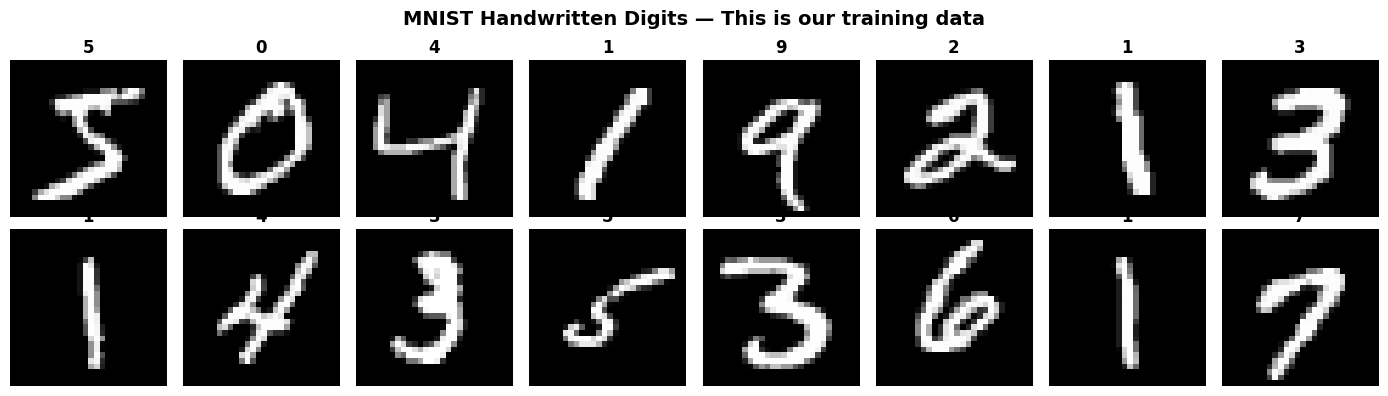

In [ ]:
# Let's SEE some digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('MNIST Handwritten Digits — This is our training data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Build the Model

In [ ]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()             # 28×28 → 784
        self.layer1 = nn.Linear(784, 256)       # 784 → 256 (learned transformation!)
        self.layer2 = nn.Linear(256, 128)       # 256 → 128 (another transformation!)
        self.layer3 = nn.Linear(128, 10)        # 128 → 10 digits (final transformation!)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)                # reshape image to vector
        x = self.relu(self.layer1(x))      # transform → activate
        x = self.relu(self.layer2(x))      # transform → activate
        x = self.layer3(x)                 # final transform → 10 scores
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DigitClassifier().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"  layer1: 784×256 matrix + 256 bias = {784*256 + 256:,} params")
print(f"  layer2: 256×128 matrix + 128 bias = {256*128 + 128:,} params")
print(f"  layer3: 128×10  matrix + 10  bias = {128*10 + 10:,} params")
print(f"\nAll parameters are MATRICES (+ biases).")
print(f"Training = finding the right transformations.")
print(f"Device: {device}")

Model architecture:
DigitClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total trainable parameters: 235,146
  layer1: 784×256 matrix + 256 bias = 200,960 params
  layer2: 256×128 matrix + 128 bias = 32,896 params
  layer3: 128×10  matrix + 10  bias = 1,290 params

All parameters are MATRICES (+ biases).
Training = finding the right transformations.
Device: cuda


### 5.3 🔥 Train It!

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# Track progress
train_losses = []
train_accs = []
test_accs = []

print("\n🔥 TRAINING STARTS NOW!\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'Time':>6}")
print("-" * 55)

for epoch in range(5):
    # --- Training ---
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # THE 5-LINE TRAINING LOOP!
        predictions = model(batch_x)          # 1. Forward pass
        loss = loss_fn(predictions, batch_y)   # 2. Compute loss
        loss.backward()                        # 3. Backward pass
        optimizer.step()                       # 4. Update weights
        optimizer.zero_grad()                  # 5. Reset gradients

        epoch_loss += loss.item()
        correct += (predictions.argmax(1) == batch_y).sum().item()
        total += len(batch_y)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct / total

    # --- Testing ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            correct += (preds.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

    test_acc = correct / total
    elapsed = time.time() - start

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"  {epoch+1:>3}  | {train_loss:>10.4f} | {train_acc:>8.1%} | {test_acc:>7.1%} | {elapsed:>5.1f}s")

print(f"\n🎉 Final test accuracy: {test_accs[-1]:.1%}")
print(f"   The model learned to recognize handwritten digits!")


🔥 TRAINING STARTS NOW!

Epoch | Train Loss | Train Acc | Test Acc |   Time
-------------------------------------------------------
    1  |     0.2282 |    93.1% |   96.5% |  17.0s
    2  |     0.0957 |    97.0% |   97.6% |  16.9s
    3  |     0.0636 |    98.0% |   96.9% |  15.7s
    4  |     0.0515 |    98.3% |   97.7% |  15.5s
    5  |     0.0377 |    98.8% |   97.8% |  15.1s

🎉 Final test accuracy: 97.8%
   The model learned to recognize handwritten digits!


### 5.4 Visualize the Learning

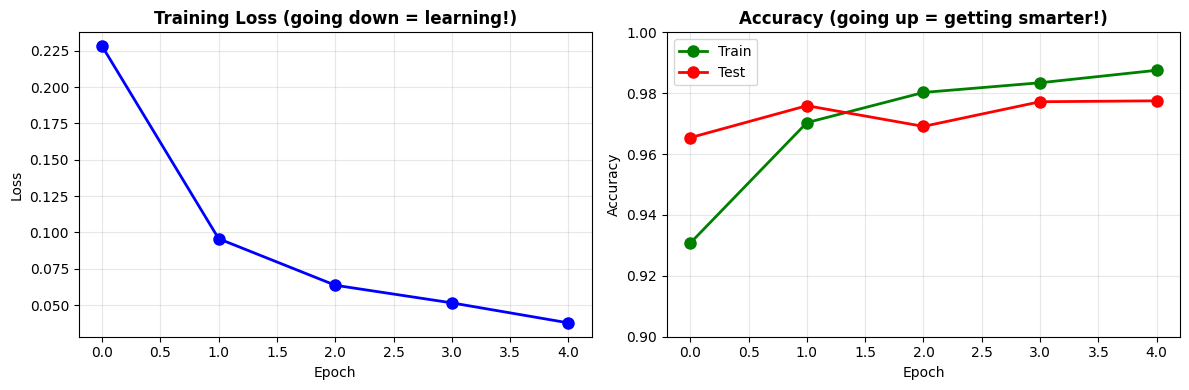

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (going down = learning!)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, 'g-o', linewidth=2, markersize=8, label='Train')
axes[1].plot(test_accs, 'r-o', linewidth=2, markersize=8, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy (going up = getting smarter!)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

### 5.5 See It in Action!
Watch the model predict on digits it has **never seen before**.

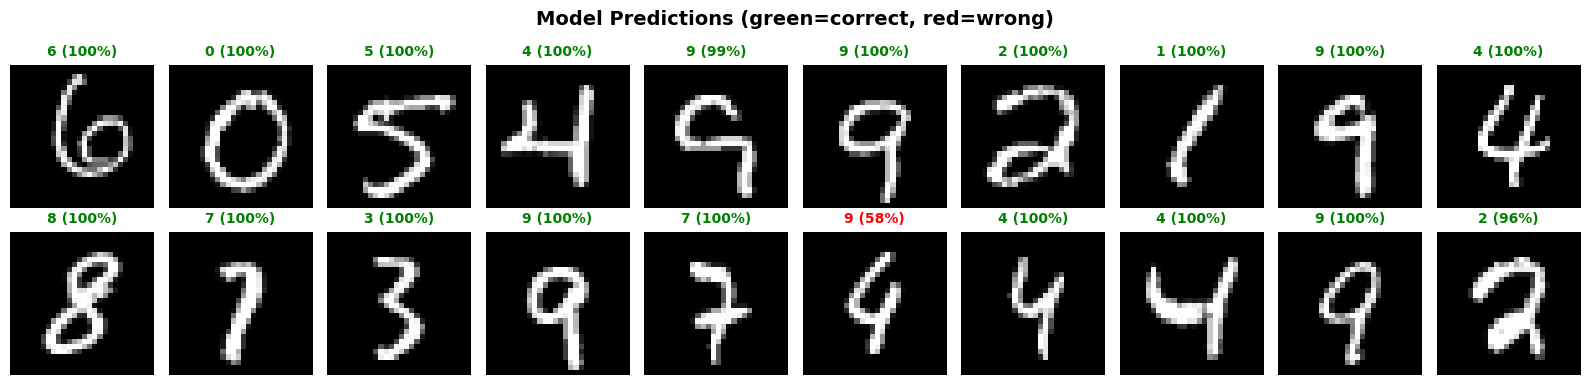

☝️ The model learned THREE matrix transformations that convert
   pixel values → digit predictions with ~97% accuracy.
   That's deep learning. That's what you built today. 🔥


In [ ]:
model.eval()
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, true_label = test_data[i + 100]
        pred = model(img.unsqueeze(0).to(device))
        pred_label = pred.argmax(1).item()
        confidence = torch.softmax(pred, dim=1).max().item()

        ax.imshow(img.squeeze(), cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'{pred_label} ({confidence:.0%})', color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

plt.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("☝️ The model learned THREE matrix transformations that convert")
print("   pixel values → digit predictions with ~97% accuracy.")
print("   That's deep learning. That's what you built today. 🔥")

### 5.6 Peek Inside — What Did the Model Learn?
Each row of the first weight matrix is a 28×28 "template" the model looks for.

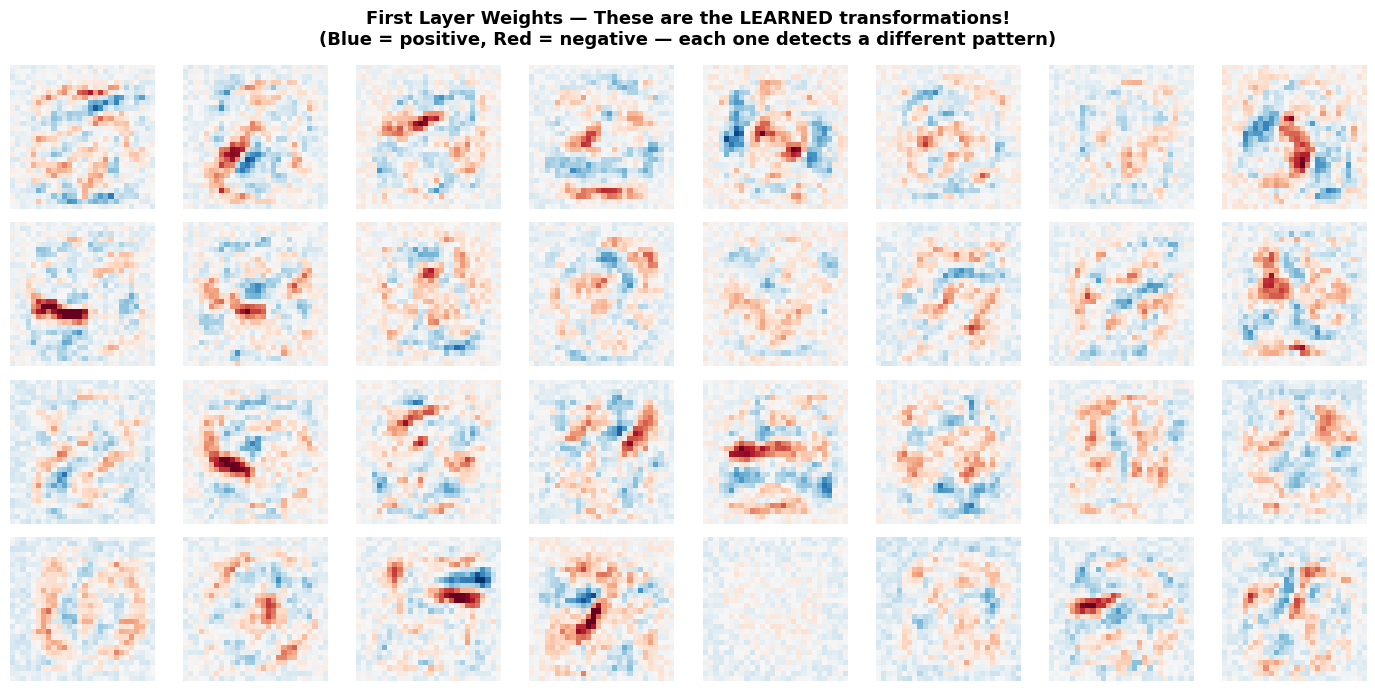

Each of these 28×28 grids is a ROW of the first weight matrix.
The model learned these patterns automatically through training.
Some look like edges, curves, or digit fragments.
This is what 'learned transformation' actually looks like!


In [ ]:
weights = model.layer1.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    w = weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu', vmin=-0.3, vmax=0.3)
    ax.axis('off')

plt.suptitle('First Layer Weights — These are the LEARNED transformations!\n'
             '(Blue = positive, Red = negative — each one detects a different pattern)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each of these 28×28 grids is a ROW of the first weight matrix.")
print("The model learned these patterns automatically through training.")
print("Some look like edges, curves, or digit fragments.")
print("This is what 'learned transformation' actually looks like!")